In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer, KNNImputer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Load dataset
df = pd.read_csv("dataset_mood_smartphone.csv")

# Initial exploration
print("Dataset shape:", df.shape)
print("\nFirst 20 rows:")
print(df.head(20))
print("\nColumn info:")
print(df.info())
print("\nUnique values in 'variable' column:")
print(df['variable'].value_counts())

Dataset shape: (376912, 5)

First 20 rows:
    Unnamed: 0       id                     time variable  value
0            1  AS14.01  2014-02-26 13:00:00.000     mood    6.0
1            2  AS14.01  2014-02-26 15:00:00.000     mood    6.0
2            3  AS14.01  2014-02-26 18:00:00.000     mood    6.0
3            4  AS14.01  2014-02-26 21:00:00.000     mood    7.0
4            5  AS14.01  2014-02-27 09:00:00.000     mood    6.0
5            6  AS14.01  2014-02-27 12:00:00.000     mood    6.0
6            7  AS14.01  2014-02-27 15:00:00.000     mood    7.0
7            8  AS14.01  2014-03-21 09:00:00.000     mood    6.0
8            9  AS14.01  2014-03-21 11:00:00.000     mood    6.0
9           10  AS14.01  2014-03-21 15:00:00.000     mood    7.0
10          11  AS14.01  2014-03-21 19:00:00.000     mood    6.0
11          12  AS14.01  2014-03-21 21:00:00.000     mood    6.0
12          13  AS14.01  2014-03-22 08:00:00.000     mood    7.0
13          14  AS14.01  2014-03-22 12:00:00.00

In [3]:
# Create comprehensive statistics table
def create_dataset_statistics(df):
    stats_df = pd.DataFrame({
        'Total Records': [len(df)],
        'Number of Users': [df['id'].nunique()],
        'Number of Variables': [df['variable'].nunique()],
        'Date Range': [f"{df['time'].min()} to {df['time'].max()}"],
        'Missing Values': [df['value'].isna().sum()],
        'Missing Percentage': [(df['value'].isna().sum()/len(df))*100]
    })
    return stats_df

stats_table = create_dataset_statistics(df)
print(stats_table)

# Per-variable statistics
variable_stats = df.groupby('variable')['value'].agg(['count', 'mean', 'std', 'min', 'max'])
print("\nPer-variable statistics:")
print(variable_stats)

   Total Records  Number of Users  Number of Variables  \
0         376912               27                   19   

                                          Date Range  Missing Values  \
0  2014-02-17 07:00:52.197 to 2014-06-09 00:00:00...             202   

   Missing Percentage  
0            0.053593  

Per-variable statistics:
                      count        mean         std        min        max
variable                                                                 
activity              22965    0.115958    0.186946      0.000      1.000
appCat.builtin        91288   18.538262  415.989243 -82798.871  33960.246
appCat.communication  74276   43.343792  128.912750      0.006   9830.777
appCat.entertainment  27125   37.576480  262.960476     -0.011  32148.677
appCat.finance          939   21.755251   39.218361      0.131    355.513
appCat.game             813  128.391615  327.145246      1.003   5491.793
appCat.office          5642   22.578892  449.601382      0.003  32708.81

                      Total  Missing  Missing %
variable                                       
circumplex.valence     5643      156       2.76
circumplex.arousal     5643       46       0.82
activity              22965        0       0.00
appCat.unknown          939        0       0.00
screen                96578        0       0.00
mood                   5641        0       0.00
call                   5239        0       0.00
appCat.weather          255        0       0.00
appCat.utilities       2487        0       0.00
appCat.travel          2846        0       0.00
appCat.builtin        91288        0       0.00
appCat.social         19145        0       0.00
appCat.other           7650        0       0.00
appCat.office          5642        0       0.00
appCat.game             813        0       0.00
appCat.finance          939        0       0.00
appCat.entertainment  27125        0       0.00
appCat.communication  74276        0       0.00
sms                    1798        0    

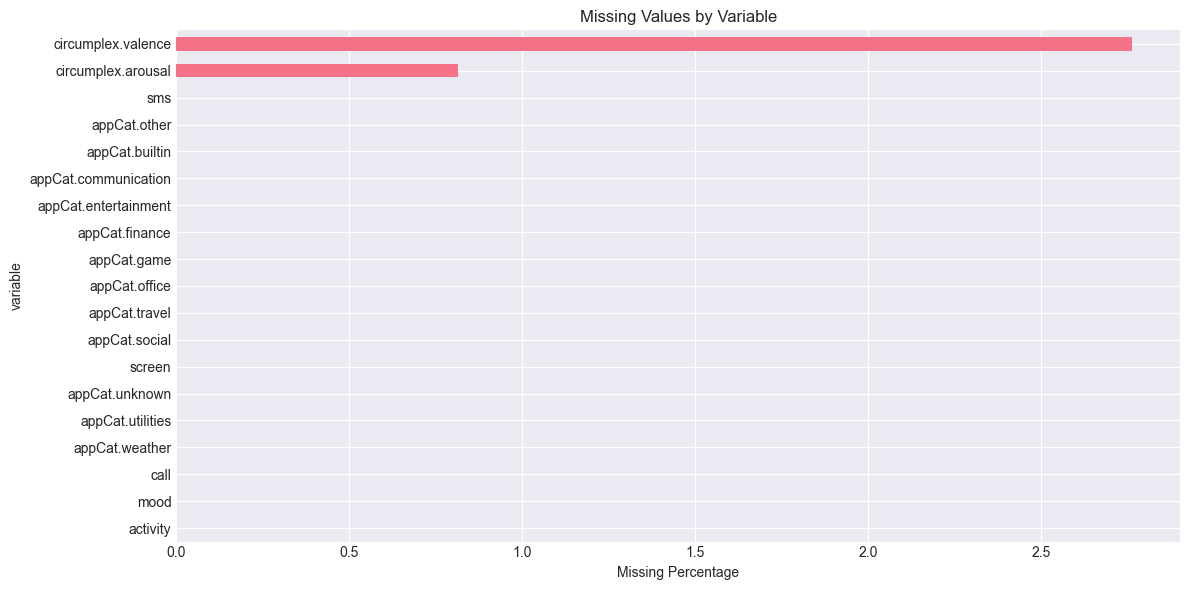

In [ ]:
# Missing values per variable
missing_per_var = df.groupby('variable')['value'].apply(lambda x: x.isna().sum())
missing_percent = (missing_per_var / df.groupby('variable').size()) * 100

missing_table = pd.DataFrame({
    'Total': df.groupby('variable').size(),
    'Missing': missing_per_var,
    'Missing %': missing_percent.round(2)
}).sort_values('Missing %', ascending=False)

print(missing_table)

# Visualize missing values
plt.figure(figsize=(12, 6))
missing_percent.sort_values().plot(kind='barh')
plt.xlabel('Missing Percentage')
plt.title('Missing Values by Variable')
plt.tight_layout()
# plt.savefig('missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

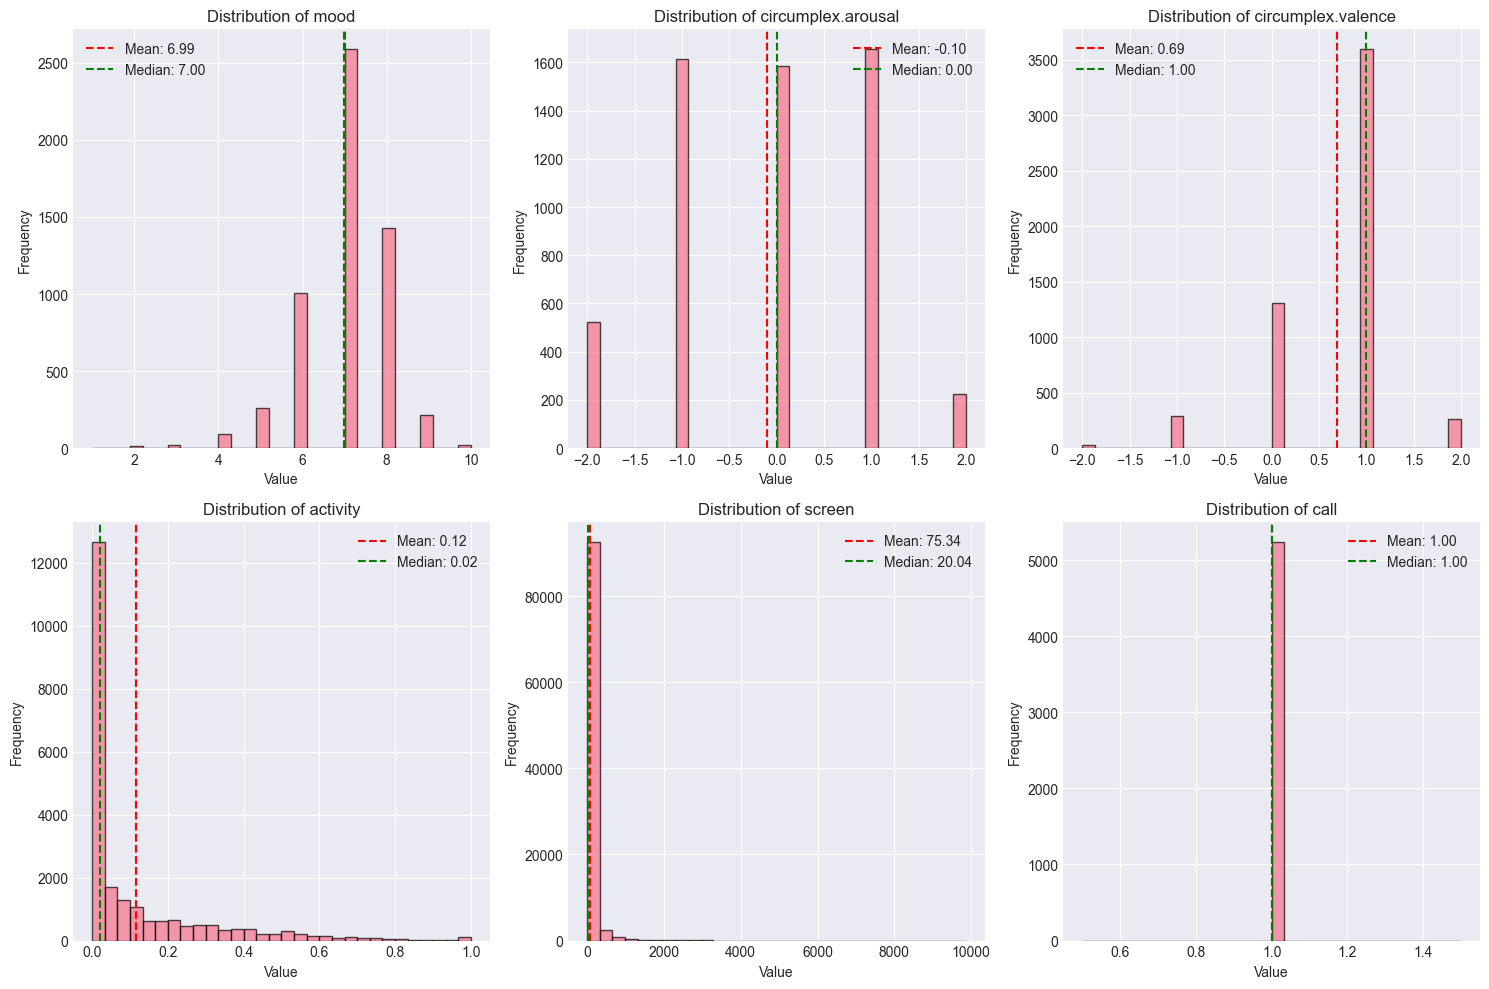

In [ ]:
# Create subplot for key variable distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
key_vars = ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity', 'screen', 'call']

for idx, var in enumerate(key_vars):
    row, col = idx // 3, idx % 3
    var_data = df[df['variable'] == var]['value'].dropna()
    
    axes[row, col].hist(var_data, bins=30, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Distribution of {var}')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    
    # Add mean/median lines
    axes[row, col].axvline(var_data.mean(), color='red', linestyle='--', label=f'Mean: {var_data.mean():.2f}')
    axes[row, col].axvline(var_data.median(), color='green', linestyle='--', label=f'Median: {var_data.median():.2f}')
    axes[row, col].legend()

plt.tight_layout()
# plt.savefig('variable_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

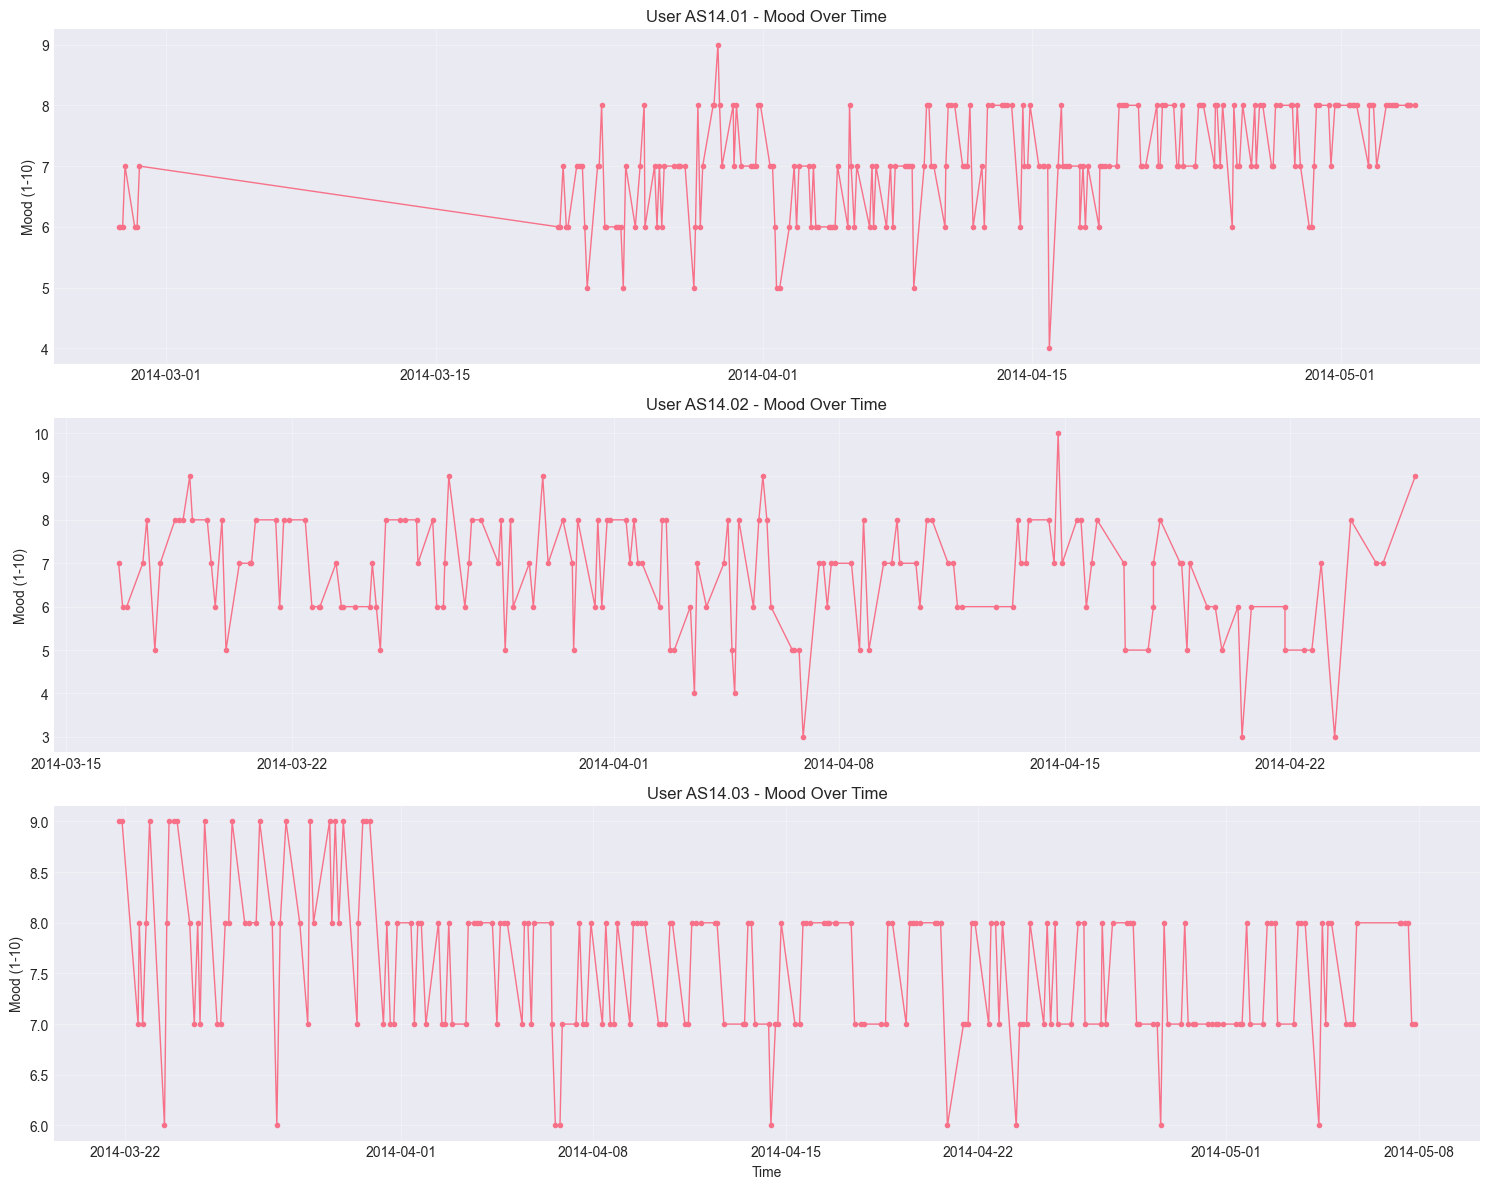

In [ ]:
# Convert time to datetime
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date

# Mood over time for a few users
sample_users = df['id'].unique()[:3]

fig, axes = plt.subplots(len(sample_users), 1, figsize=(15, 12))

for idx, user in enumerate(sample_users):
    user_mood = df[(df['id'] == user) & (df['variable'] == 'mood')].copy()
    user_mood = user_mood.sort_values('time')
    
    axes[idx].plot(user_mood['time'], user_mood['value'], marker='o', markersize=3, linewidth=1)
    axes[idx].set_title(f'User {user} - Mood Over Time')
    axes[idx].set_ylabel('Mood (1-10)')
    axes[idx].grid(True, alpha=0.3)

plt.xlabel('Time')
plt.tight_layout()
# plt.savefig('mood_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

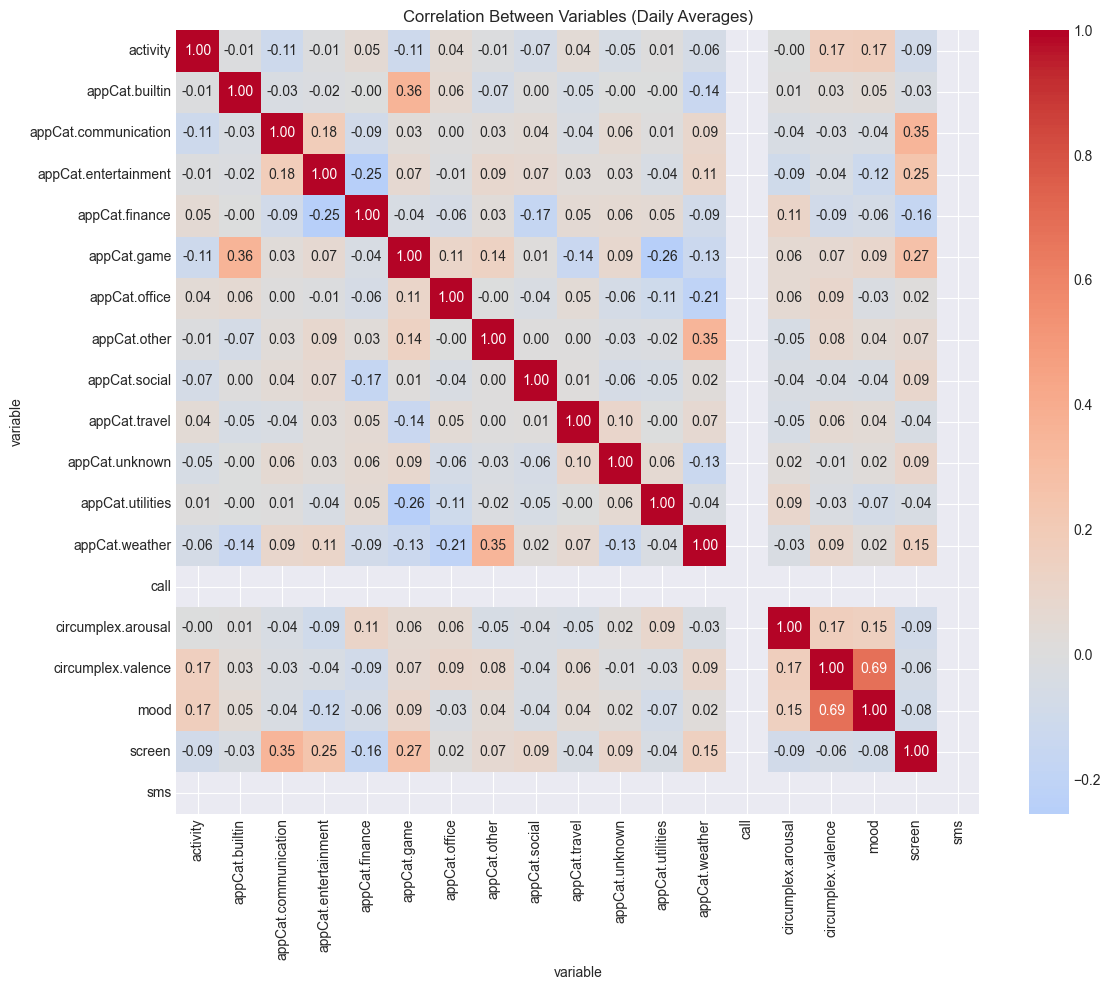


Variables most correlated with mood:
variable
mood                    1.000000
circumplex.valence      0.685227
activity                0.167145
circumplex.arousal      0.152953
appCat.game             0.089090
appCat.builtin          0.047840
appCat.travel           0.041384
appCat.other            0.040545
appCat.unknown          0.021765
appCat.weather          0.021385
appCat.office          -0.025975
appCat.communication   -0.037489
appCat.social          -0.041086
appCat.finance         -0.059631
appCat.utilities       -0.070845
screen                 -0.082161
appCat.entertainment   -0.117136
call                         NaN
sms                          NaN
Name: mood, dtype: float64


In [7]:
# Pivot data for correlation (need daily aggregates first)
daily_user_data = df.pivot_table(
    index=['id', 'date'], 
    columns='variable', 
    values='value',
    aggfunc='mean'
).reset_index()

# Correlation matrix for numeric columns
numeric_cols = daily_user_data.select_dtypes(include=[np.number]).columns
corr_matrix = daily_user_data[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Variables (Daily Averages)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Mood correlations
mood_correlations = corr_matrix['mood'].sort_values(ascending=False)
print("\nVariables most correlated with mood:")
print(mood_correlations)

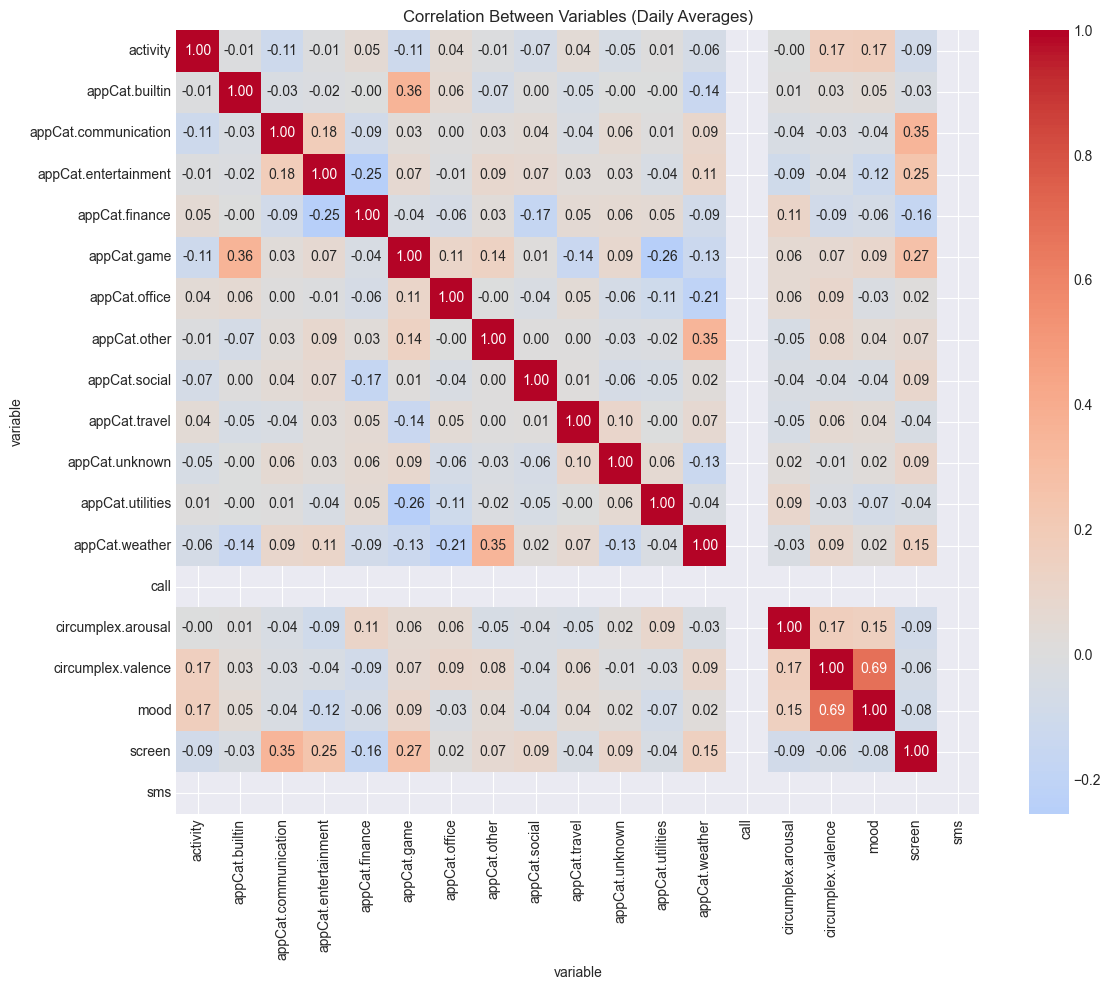


Variables most correlated with mood:
variable
mood                    1.000000
circumplex.valence      0.685227
activity                0.167145
circumplex.arousal      0.152953
appCat.game             0.089090
appCat.builtin          0.047840
appCat.travel           0.041384
appCat.other            0.040545
appCat.unknown          0.021765
appCat.weather          0.021385
appCat.office          -0.025975
appCat.communication   -0.037489
appCat.social          -0.041086
appCat.finance         -0.059631
appCat.utilities       -0.070845
screen                 -0.082161
appCat.entertainment   -0.117136
call                         NaN
sms                          NaN
Name: mood, dtype: float64


In [8]:
# Pivot data for correlation (need daily aggregates first)
daily_user_data = df.pivot_table(
    index=['id', 'date'], 
    columns='variable', 
    values='value',
    aggfunc='mean'
).reset_index()

# Correlation matrix for numeric columns
numeric_cols = daily_user_data.select_dtypes(include=[np.number]).columns
corr_matrix = daily_user_data[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Variables (Daily Averages)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Mood correlations
mood_correlations = corr_matrix['mood'].sort_values(ascending=False)
print("\nVariables most correlated with mood:")
print(mood_correlations)

Data cleaning!

In [9]:
def detect_outliers_iqr(df, variable, multiplier=1.5):
    """Detect outliers using IQR method"""
    var_data = df[df['variable'] == variable]['value'].dropna()
    Q1 = var_data.quantile(0.25)
    Q3 = var_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return lower_bound, upper_bound

def detect_outliers_zscore(df, variable, threshold=3):
    """Detect outliers using Z-score method"""
    var_data = df[df['variable'] == variable]['value'].dropna()
    z_scores = np.abs(stats.zscore(var_data))
    return z_scores > threshold

# Apply outlier detection
outlier_summary = {}
for var in df['variable'].unique():
    lower, upper = detect_outliers_iqr(df, var)
    var_data = df[df['variable'] == var]['value'].dropna()
    outliers = var_data[(var_data < lower) | (var_data > upper)]
    outlier_summary[var] = {
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': len(outliers),
        'outlier_percentage': (len(outliers) / len(var_data)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print("Outlier detection results (IQR method):")
print(outlier_df)

# Remove outliers (using IQR method)
cleaned_dfs = []
for var in df['variable'].unique():
    var_df = df[df['variable'] == var].copy()
    lower, upper = detect_outliers_iqr(df, var)
    var_df_cleaned = var_df[(var_df['value'].isna()) | ((var_df['value'] >= lower) & (var_df['value'] <= upper))]
    cleaned_dfs.append(var_df_cleaned)

df_cleaned = pd.concat(cleaned_dfs, ignore_index=True)
print(f"\nOriginal rows: {len(df)}")
print(f"Cleaned rows: {len(df_cleaned)}")
print(f"Removed: {len(df) - len(df_cleaned)} rows ({((len(df)-len(df_cleaned))/len(df))*100:.2f}%)")

Outlier detection results (IQR method):
                      lower_bound  upper_bound  outlier_count  \
mood                     5.500000     9.500000          400.0   
circumplex.arousal      -4.000000     4.000000            0.0   
circumplex.valence      -1.500000     2.500000           31.0   
activity                -0.237500     0.395833         2223.0   
screen                 -80.504750   148.367250        10055.0   
call                     1.000000     1.000000            0.0   
sms                      1.000000     1.000000            0.0   
appCat.builtin          -9.833000    21.775000        10152.0   
appCat.communication   -55.168625   105.862375         6401.0   
appCat.entertainment   -19.048000    35.304000         4517.0   
appCat.finance         -20.052500    44.279500          118.0   
appCat.game           -150.067500   287.840500           85.0   
appCat.office           -7.055625    17.103375          848.0   
appCat.other            -7.696375    31.544625    

In [44]:
# Approach 1: Forward fill (propagate last valid observation)
def forward_fill_imputation(df):
    df_ffill = df.copy()
    df_ffill = df_ffill.sort_values(['id', 'time'])
    
    for user in df_ffill['id'].unique():
        for var in df_ffill['variable'].unique():
            mask = (df_ffill['id'] == user) & (df_ffill['variable'] == var)
            df_ffill.loc[mask, 'value'] = df_ffill.loc[mask, 'value'].fillna(method='ffill')
    
    # Any remaining NAs? Fill with median per user-variable
    for user in df_ffill['id'].unique():
        for var in df_ffill['variable'].unique():
            mask = (df_ffill['id'] == user) & (df_ffill['variable'] == var)
            median_val = df_ffill.loc[mask, 'value'].median()
            df_ffill.loc[mask, 'value'] = df_ffill.loc[mask, 'value'].fillna(median_val)
    
    return df_ffill

df_ffill = forward_fill_imputation(df_cleaned)
print(f"Forward fill completed. Remaining NAs: {df_ffill['value'].isna().sum()}")

Forward fill completed. Remaining NAs: 0


In [45]:
# # Approach 2: KNN Imputation (requires pivot to wide format first)
# def prepare_for_knn(df):
#     """Pivot data to wide format for KNN imputation"""
#     # Create time-window features (e.g., hour of day)
#     df['hour'] = pd.to_datetime(df['time']).dt.hour
#     df['day_of_week'] = pd.to_datetime(df['time']).dt.dayofweek
    
#     # Pivot
#     wide_df = df.pivot_table(
#         index=['id', 'time', 'hour', 'day_of_week'],
#         columns='variable',
#         values='value'
#     ).reset_index()
    
#     return wide_df

# def knn_imputation(df_wide, n_neighbors=5):
#     """Apply KNN imputation"""
#     # Select numeric columns for imputation
#     numeric_cols = df_wide.select_dtypes(include=[np.number]).columns
#     df_numeric = df_wide[numeric_cols]
    
#     # KNN Imputer
#     imputer = KNNImputer(n_neighbors=n_neighbors, weights='distance')
#     df_imputed_array = imputer.fit_transform(df_numeric)
    
#     # Convert back to DataFrame
#     df_imputed = pd.DataFrame(df_imputed_array, columns=numeric_cols, index=df_wide.index)
    
#     # Add back non-numeric columns
#     for col in ['id', 'time']:
#         if col in df_wide.columns:
#             df_imputed[col] = df_wide[col].values
    
#     return df_imputed

# # Apply KNN imputation
# wide_df = prepare_for_knn(df_cleaned)
# df_knn_imputed = knn_imputation(wide_df)

# # Convert back to long format
# def wide_to_long(df_wide):
#     long_df = pd.melt(
#         df_wide, 
#         id_vars=['id', 'time'], 
#         value_vars=[col for col in df_wide.columns if col not in ['id', 'time']],
#         var_name='variable', 
#         value_name='value'
#     )
#     return long_df

# df_knn_long = wide_to_long(df_knn_imputed)
# print(f"KNN imputation completed. Shape: {df_knn_long.shape}")

Comparing missing values approaches

In [46]:
# # Compare distributions before and after imputation
# fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# comparison_vars = ['mood', 'activity', 'screen']

# for idx, var in enumerate(comparison_vars):
#     # Original (before imputation)
#     original_data = df_cleaned[df_cleaned['variable'] == var]['value'].dropna()
#     # Forward fill
#     ffill_data = df_ffill[df_ffill['variable'] == var]['value'].dropna()
#     # KNN
#     knn_data = df_knn_long[df_knn_long['variable'] == var]['value'].dropna()
    
#     axes[0, idx].hist(original_data, bins=30, alpha=0.5, label='Original', density=True)
#     axes[0, idx].hist(ffill_data, bins=30, alpha=0.5, label='Forward Fill', density=True)
#     axes[0, idx].set_title(f'{var} - Original vs Forward Fill')
#     axes[0, idx].legend()
    
#     axes[1, idx].hist(original_data, bins=30, alpha=0.5, label='Original', density=True)
#     axes[1, idx].hist(knn_data, bins=30, alpha=0.5, label='KNN', density=True)
#     axes[1, idx].set_title(f'{var} - Original vs KNN')
#     axes[1, idx].legend()

# plt.tight_layout()
# plt.savefig('imputation_comparison.png', dpi=300, bbox_inches='tight')
# plt.show()

# # Statistical comparison
# print("\nStatistical comparison (mood variable):")
# original_stats = df_cleaned[df_cleaned['variable'] == 'mood']['value'].describe()
# ffill_stats = df_ffill[df_ffill['variable'] == 'mood']['value'].describe()
# knn_stats = df_knn_long[df_knn_long['variable'] == 'mood']['value'].describe()

# comparison_df = pd.DataFrame({
#     'Original': original_stats,
#     'Forward Fill': ffill_stats,
#     'KNN': knn_stats
# })
# print(comparison_df)

# # Choose approach (based on time series nature, forward fill is often more appropriate)
# df_final = df_ffill.copy()  # Choose forward fill for time series

Feature engineering

In [48]:
def create_daily_aggregates(df):
    """Create daily aggregated features for each user"""
    # Ensure we have date
    df['date'] = pd.to_datetime(df['time']).dt.date
    
    # Pivot to daily aggregates
    daily_data = df.pivot_table(
        index=['id', 'date'],
        columns='variable',
        values='value',
        aggfunc='mean'  # Average for continuous variables
    ).reset_index()
    
    return daily_data

# daily_df = create_daily_aggregates(df_final)
daily_df = create_daily_aggregates(df_ffill)
print(f"Daily aggregated data shape: {daily_df.shape}")
print(daily_df.head())

Daily aggregated data shape: (1973, 21)
variable       id        date  activity  appCat.builtin  appCat.communication  \
0         AS14.01  2014-02-17       NaN             NaN                   NaN   
1         AS14.01  2014-02-18       NaN             NaN                   NaN   
2         AS14.01  2014-02-19       NaN             NaN                   NaN   
3         AS14.01  2014-02-20       NaN             NaN                   NaN   
4         AS14.01  2014-02-21       NaN             NaN                   NaN   

variable  appCat.entertainment  appCat.finance  appCat.game  appCat.office  \
0                          NaN             NaN          NaN            NaN   
1                          NaN             NaN          NaN            NaN   
2                          NaN             NaN          NaN            NaN   
3                          NaN             NaN          NaN            NaN   
4                          NaN             NaN          NaN            NaN   

vari

In [57]:
# daily_df already has columns: 'id', 'date', 'mood', 'activity', 'screen', 'call', 'sms',
# and all appCat.* columns

# Convert date to datetime
daily_df['date'] = pd.to_datetime(daily_df['date'])

# Separate app columns from other columns
app_cols = [col for col in daily_df.columns if 'appCat' in col]
other_cols = [col for col in daily_df.columns if col not in app_cols + ['id', 'date']]

# 1. For app columns: fill NaN with 0 (app not used)
daily_df[app_cols] = daily_df[app_cols].fillna(0)

# 2. For other columns: resample to daily and forward fill per user
def resample_and_fill(user_df, other_cols):
    user_df = user_df.set_index('date')
    # Resample to daily (fills missing dates)
    user_df = user_df.resample('D').asfreq()
    # Forward fill the other columns
    user_df[other_cols] = user_df[other_cols].ffill()
    return user_df.reset_index()

# Apply to each user
daily_df_filled = daily_df.groupby('id').apply(
    lambda g: resample_and_fill(g, other_cols)
).reset_index(drop=True)

# After resampling, ensure no NaNs remain in other_cols (e.g., first days)
# Optionally, backfill the first few days with the next available value
daily_df_filled[other_cols] = daily_df_filled[other_cols].bfill()

In [58]:
def create_lag_features(df, target_var='mood', lag_days=[1, 2, 3, 5, 7]):
    """Create lag features for time series prediction"""
    df_lagged = df.copy()
    df_lagged = df_lagged.sort_values(['id', 'date'])
    
    for lag in lag_days:
        df_lagged[f'{target_var}_lag_{lag}'] = df_lagged.groupby('id')[target_var].shift(lag)
    
    return df_lagged

def create_rolling_features(df, target_var='mood', windows=[3, 5, 7]):
    """Create rolling window statistics"""
    df_rolled = df.copy()
    df_rolled = df_rolled.sort_values(['id', 'date'])
    
    for window in windows:
        df_rolled[f'{target_var}_rolling_mean_{window}'] = df_rolled.groupby('id')[target_var].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df_rolled[f'{target_var}_rolling_std_{window}'] = df_rolled.groupby('id')[target_var].transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )
    
    return df_rolled

# Apply feature engineering
daily_with_lags = create_lag_features(daily_df)
daily_with_rolling = create_rolling_features(daily_with_lags)

print(f"Features after engineering: {daily_with_rolling.shape[1]}")
print("New features created:")
new_features = [col for col in daily_with_rolling.columns if 'lag' in col or 'rolling' in col]
print(new_features)

Features after engineering: 32
New features created:
['mood_lag_1', 'mood_lag_2', 'mood_lag_3', 'mood_lag_5', 'mood_lag_7', 'mood_rolling_mean_3', 'mood_rolling_std_3', 'mood_rolling_mean_5', 'mood_rolling_std_5', 'mood_rolling_mean_7', 'mood_rolling_std_7']


In [59]:
def create_target_variable(df, target_var='mood'):
    """Create target: next day's average mood"""
    df_with_target = df.copy()
    df_with_target = df_with_target.sort_values(['id', 'date'])
    df_with_target['target_mood_next_day'] = df_with_target.groupby('id')[target_var].shift(-1)
    
    # Remove rows where target is NaN (last day for each user)
    df_with_target = df_with_target.dropna(subset=['target_mood_next_day'])
    
    return df_with_target

# Create final dataset for modeling
final_dataset = create_target_variable(daily_with_rolling)
print(f"Final dataset shape: {final_dataset.shape}")
print(f"Number of complete instances: {len(final_dataset)}")

Final dataset shape: (1262, 33)
Number of complete instances: 1262


In [60]:
# def detect_prolonged_missing(df, max_gap_days=5):
#     """Identify and handle prolonged missing periods"""
#     df_gap = df.copy()
#     df_gap = df_gap.sort_values(['id', 'date'])
    
#     # Calculate gaps between consecutive records per user
#     df_gap['prev_date'] = df_gap.groupby('id')['date'].shift(1)
#     df_gap['gap_days'] = (pd.to_datetime(df_gap['date']) - pd.to_datetime(df_gap['prev_date'])).dt.days
    
#     # Flag large gaps
#     large_gaps = df_gap[df_gap['gap_days'] > max_gap_days]
    
#     print(f"Found {len(large_gaps)} instances with gaps > {max_gap_days} days")
#     print(f"This represents {len(large_gaps)/len(df_gap)*100:.2f}% of data")
    
#     # Option 1: Remove sequences with too many gaps
#     # Option 2: Create separate sequences for each continuous block
    
#     return df_gap

# final_dataset = detect_prolonged_missing(final_dataset)

Class distribution:
mood_class
1    647
2    615
Name: count, dtype: int64
mood_class
1    0.512678
2    0.487322
Name: proportion, dtype: float64


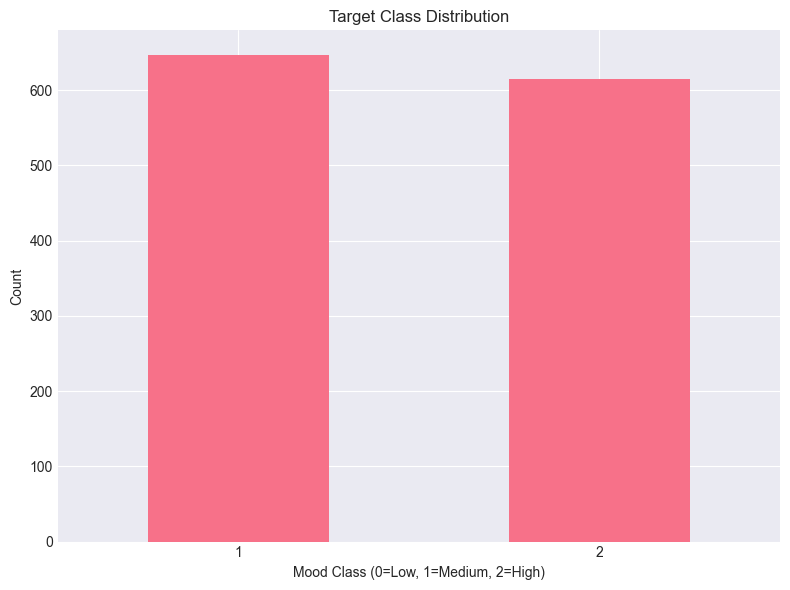

In [61]:
# Convert regression target to classification (3 classes: low, medium, high mood)
def discretize_mood(mood_value):
    if mood_value <= 4:
        return 0  # Low mood
    elif mood_value <= 7:
        return 1  # Medium mood
    else:
        return 2  # High mood

final_dataset['mood_class'] = final_dataset['target_mood_next_day'].apply(discretize_mood)

print("Class distribution:")
print(final_dataset['mood_class'].value_counts())
print(final_dataset['mood_class'].value_counts(normalize=True))

# Visualize class distribution
plt.figure(figsize=(8, 6))
final_dataset['mood_class'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Mood Class (0=Low, 1=Medium, 2=High)')
plt.ylabel('Count')
plt.title('Target Class Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
# plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [62]:
# Define feature columns (exclude non-feature columns)
exclude_cols = ['id', 'date', 'target_mood_next_day', 'mood_class', 'prev_date', 'gap_days']
feature_cols = [col for col in final_dataset.columns if col not in exclude_cols]

# Handle any remaining missing values
final_dataset_clean = final_dataset.dropna(subset=feature_cols)

X = final_dataset_clean[feature_cols]
y = final_dataset_clean['mood_class']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures: {feature_cols[:10]}...")  # First 10 features

Feature matrix shape: (210, 30)
Target vector shape: (210,)

Features: ['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel']...


Time series cross validation setup

In [63]:
# For time series, use TimeSeriesSplit (not random shuffle)
tscv = TimeSeriesSplit(n_splits=5)

def evaluate_model_time_series(model, X, y, model_name):
    """Evaluate model using time series cross-validation"""
    scores = []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train and predict
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        # Evaluate
        accuracy = accuracy_score(y_test, y_pred)
        scores.append(accuracy)
    
    print(f"{model_name} - Mean Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")
    return scores

# Split data chronologically (80/20 temporal split)
split_point = int(len(X) * 0.8)
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 168
Test set size: 42


Approach 1 random forest classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameter optimization
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use TimeSeriesSplit for grid search
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search_rf = GridSearchCV(
    rf_base, param_grid_rf, 
    cv=TimeSeriesSplit(n_splits=3), 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

grid_search_rf.fit(X_train_scaled, y_train)
best_rf = grid_search_rf.best_estimator_

print(f"Best Random Forest parameters: {grid_search_rf.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_rf.best_score_:.4f}")

# Evaluate on test set
y_pred_rf = best_rf.predict(X_test_scaled)
test_accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {test_accuracy_rf:.4f}")

# Classification report
print("\nRandom Forest Classification Report:")
# print(classification_report(y_test, y_pred_rf, target_names=['Low', 'Medium', 'High']))
print(classification_report(y_test, y_pred_rf))

Fitting 3 folds for each of 900 candidates, totalling 2700 fits
Best Random Forest parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 300}
Best cross-validation accuracy: 0.6429
Random Forest Test Accuracy: 0.7381

Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.67      0.78      0.72        18
           2       0.81      0.71      0.76        24

    accuracy                           0.74        42
   macro avg       0.74      0.74      0.74        42
weighted avg       0.75      0.74      0.74        42



Approach 2 LSTM

In [67]:
# Prepare sequences for LSTM
def create_sequences(data, target, seq_length=7):
    """Create sequences for LSTM"""
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(target[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

# Prepare sequence data
seq_length = 7  # Use past 7 days
X_seq, y_seq = create_sequences(X_train_scaled, y_train, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, seq_length)

print(f"LSTM input shape: {X_seq.shape}")

# Build LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# One-hot encode targets for LSTM
y_seq_categorical = to_categorical(y_seq, num_classes=3)
y_test_seq_categorical = to_categorical(y_test_seq, num_classes=3)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, X_train_scaled.shape[1])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train LSTM
history = lstm_model.fit(
    X_seq, y_seq_categorical,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

# Evaluate LSTM
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_seq, y_test_seq_categorical)
print(f"LSTM Test Accuracy: {lstm_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
# plt.savefig('lstm_training.png', dpi=300, bbox_inches='tight')
plt.show()

KeyError: 7

Comparing classification algorithms

In [ ]:
# Comparison visualization
models = ['Random Forest', 'LSTM']
accuracies = [test_accuracy_rf, lstm_accuracy]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy')
plt.title('Classification Algorithm Comparison')
plt.ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('classification_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== CLASSIFICATION SUMMARY ===")
print(f"Random Forest Accuracy: {test_accuracy_rf:.4f}")
print(f"LSTM Accuracy: {lstm_accuracy:.4f}")
print(f"Improvement with LSTM: {(lstm_accuracy - test_accuracy_rf)*100:.2f}%")